# Wine Quality Classification
## Comparative Study between Decision Tree and Support Vector Machine (SVM)

### Importing Neccessary Libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Reading the dataset

In [38]:
df = pd.read_csv("D:\winequality-white.csv",delimiter=";")
print(df.shape)

(4898, 12)


In [39]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [41]:
#our dataset is not having any null values

In [42]:
df.duplicated().sum()

np.int64(937)

### Using library to get basic analysis on data, to find relation between various attributes, and report of whole dataset.

In [43]:
from ydata_profiling import ProfileReport

prof = ProfileReport(df)

prof.to_file(output_file="EDA_output.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 3658.89it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

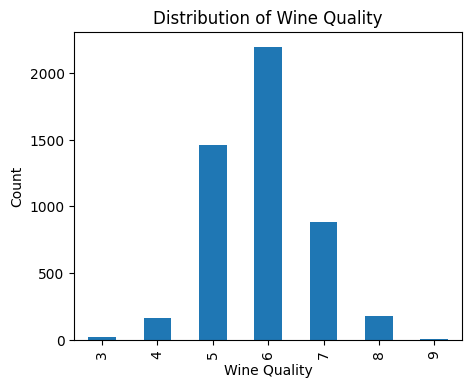

In [44]:
plt.figure(figsize=(5, 4))
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Wine Quality')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality')
plt.show()

#### Hence our data is unbalanced. 
#### So classifying each wine quality as 3,4,5,6,7,8,9 will make the model overfit to training data, 
#### so we will do binary classification we found that a minimum of 7 score is compulsory for a wine to be called good.


##### https://concannon.wine/wine-ratings-explained/ - website for referencing for grading wine
##### 95-100: A classic, superior wine
##### 90-94: An all-around phenomenal wine
##### 85-89: A very good wine with strong qualities
##### 80-84: A good wine that is worth enjoying
##### 75-79: A drinkable wine that is not hugely recommended
##### 74 or below: This wine is not recommended, a poorly-made and flawed wine

### BIVARIATE ANALYSIS

In [47]:
df.corr()['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.435575
pH                      0.099427
sulphates               0.053678
free sulfur dioxide     0.008158
citric acid            -0.009209
residual sugar         -0.097577
fixed acidity          -0.113663
total sulfur dioxide   -0.174737
volatile acidity       -0.194723
chlorides              -0.209934
density                -0.307123
Name: quality, dtype: float64

In [48]:
df['quality']=df['quality'].apply(lambda y_value: 1 if y_value >=7 else 0)

In [49]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,0
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,0
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,0
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1


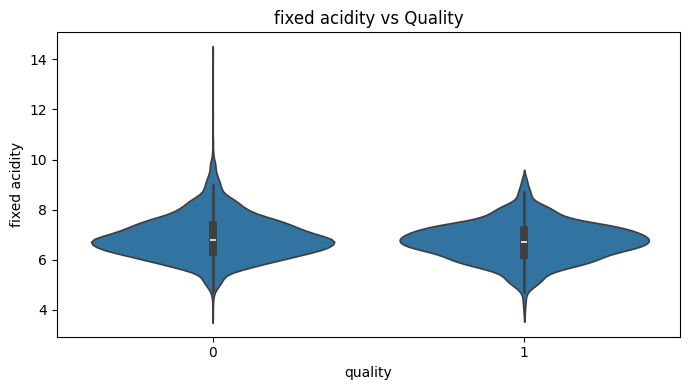

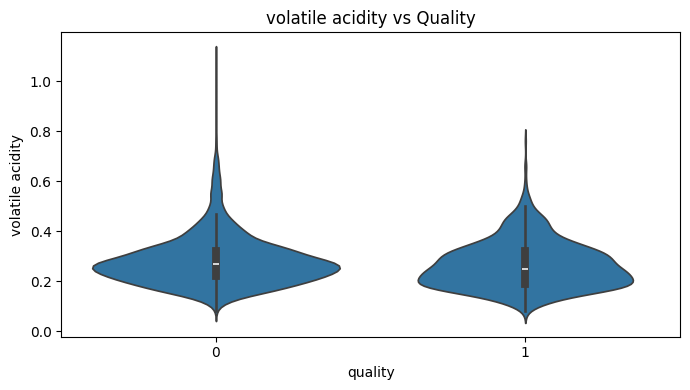

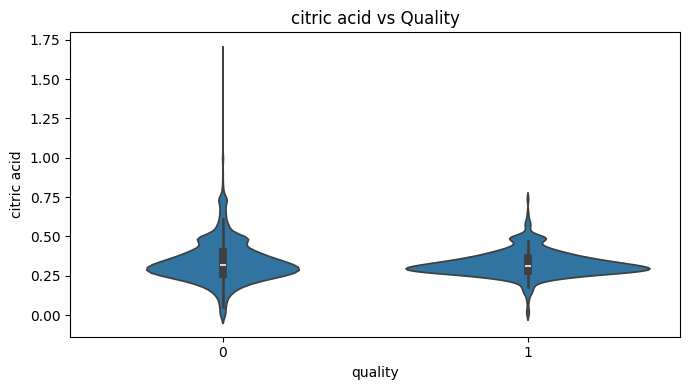

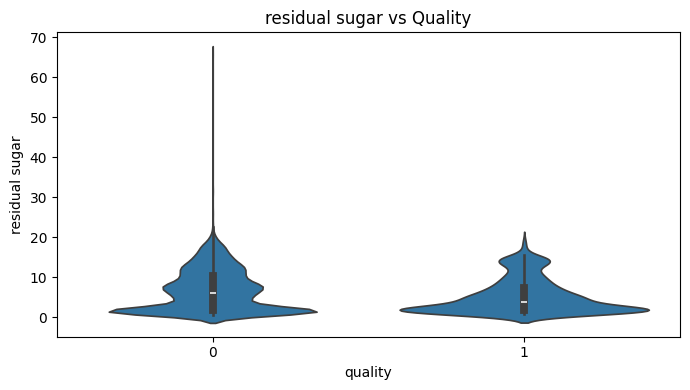

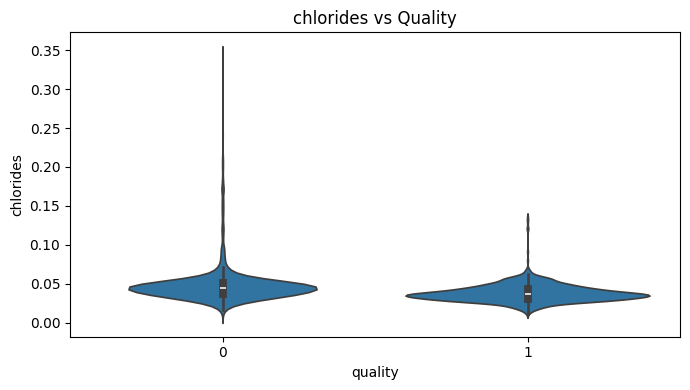

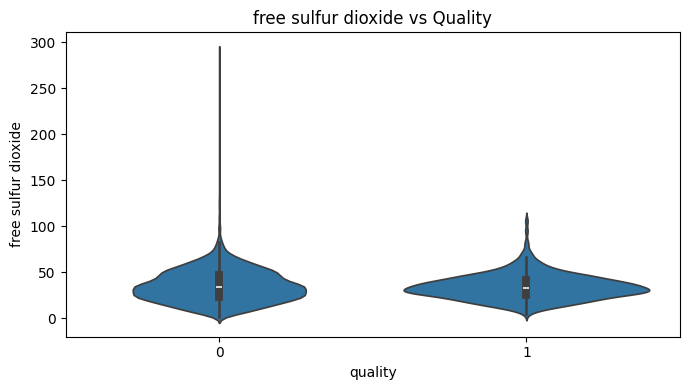

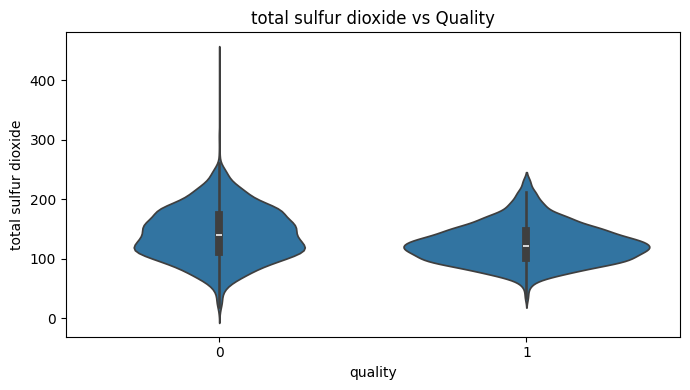

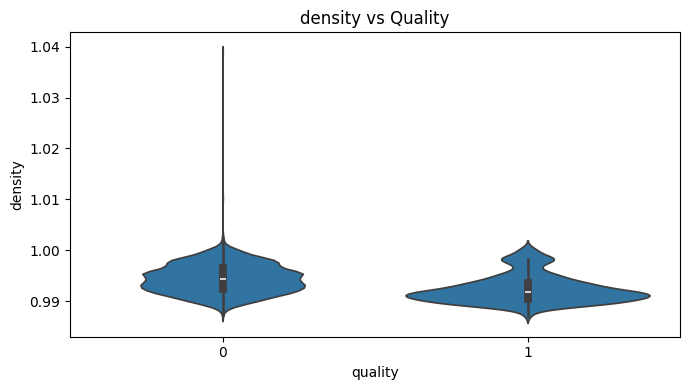

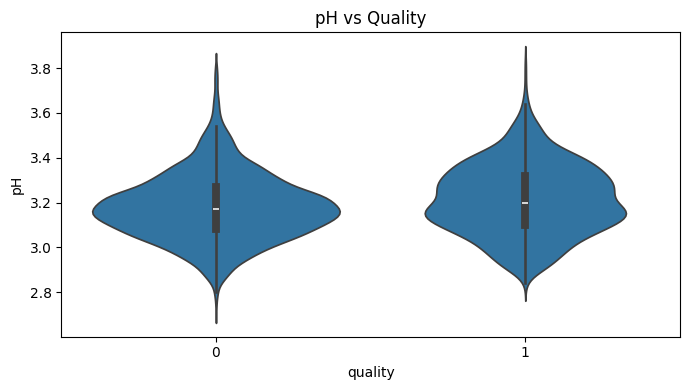

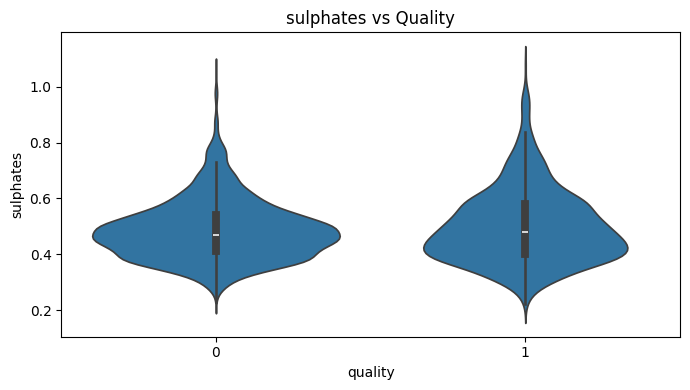

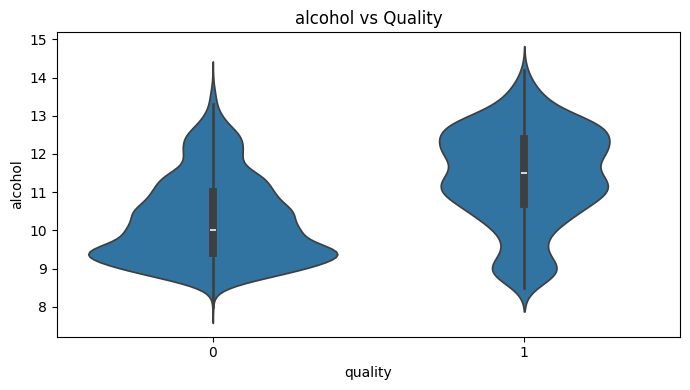

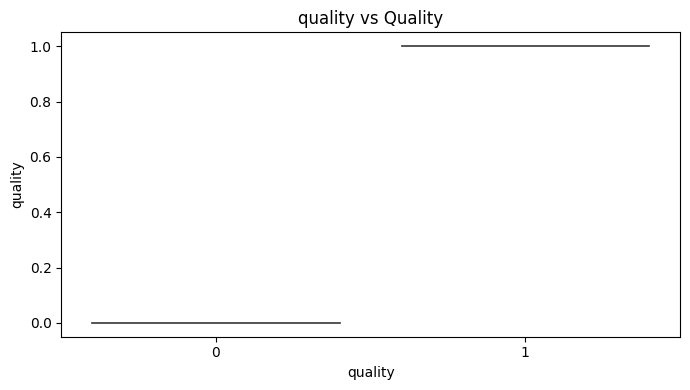

In [50]:
for col in df.columns:
    plt.figure(figsize=(7, 4))
    sns.violinplot(data=df, x='quality', y=col)
    plt.title(f'{col} vs Quality')
    plt.tight_layout()
    plt.show()

#### High-quality wines tend to have lower density than low-quality wines.
####     Higher-quality wines tend to have higher alcohol content.

## Training of Model
### Step 1: Data Preprocessing

In [52]:
X=df.drop("quality",axis=1)
y=df['quality']
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3918, 11) (980, 11) (3918,) (980,)


Fitting 5 folds for each of 3072 candidates, totalling 15360 fits
Best CV weighted-F1: 0.8169249424421418
Best params: {'tree__ccp_alpha': 0.0005, 'tree__class_weight': None, 'tree__criterion': 'entropy', 'tree__max_depth': None, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.85      0.88       768
           1       0.58      0.74      0.65       212

    accuracy                           0.83       980
   macro avg       0.75      0.79      0.77       980
weighted avg       0.85      0.83      0.83       980



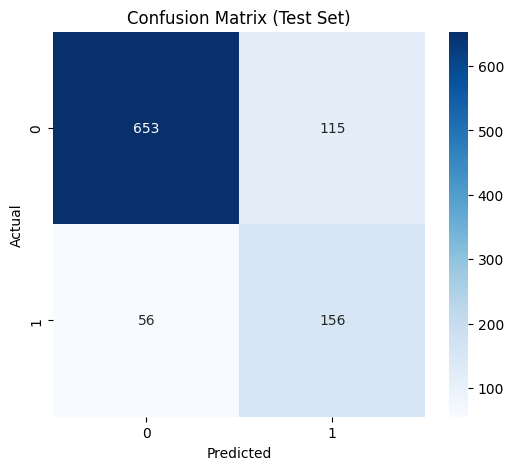

In [58]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    f1_score,
)
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
# ---------------------------------------------------------------
# 4. Pipeline: SMOTE (train-fold only, thanks to imblearn.Pipeline)
#    -> Decision Tree
# ---------------------------------------------------------------
pipeline = Pipeline([
    ("oversampler", SMOTE(random_state=RANDOM_STATE)),
    ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE)),
])
 
param_grid = {
    "tree__criterion": ["gini", "entropy"],
    "tree__max_depth": [3, 4, 5, 6, 7, 8, 10, None],
    "tree__min_samples_split": [2, 5, 10, 20],
    "tree__min_samples_leaf": [1, 2, 5, 10],
    "tree__ccp_alpha": [0.0, 0.0005, 0.001, 0.0016, 0.002, 0.005],
    "tree__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

print("Best CV weighted-F1:", grid.best_score_)
print("Best params:", grid.best_params_)

dt_model = grid.best_estimator_

# ---------------------------------------------------------------
# 6. FINAL evaluation on the untouched test set.
#    This is the only place the test set is used.
# ---------------------------------------------------------------
y_pred = dt_model.predict(X_test)
print("\nFinal Test Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()

In [59]:

y_pred_on_train = dt_model.predict(X_train)
print(classification_report(y_train, y_pred_on_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3070
           1       0.98      0.98      0.98       848

    accuracy                           0.99      3918
   macro avg       0.99      0.99      0.99      3918
weighted avg       0.99      0.99      0.99      3918



## Feature importance: 
### Gini (fast, but biased/unstable under correlated features)
###  AND permutation importance (slower, resampling-based, more trustworthy) side by side.

In [61]:
gini_importance = pd.Series(
    dt_model.named_steps["tree"].feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)
print("\nGini importance:\n", gini_importance)

perm_result = permutation_importance(
    dt_model, X_test, y_test,
    n_repeats=20, random_state=RANDOM_STATE, scoring="f1_macro", n_jobs=-1,
)
perm_importance = pd.Series(
    perm_result.importances_mean, index=X_train.columns
).sort_values(ascending=False)
print("\nPermutation importance (test set):\n", perm_importance)


Gini importance:
 alcohol                 0.235024
volatile acidity        0.116930
citric acid             0.090209
total sulfur dioxide    0.087217
free sulfur dioxide     0.086946
residual sugar          0.084518
chlorides               0.066053
density                 0.064381
pH                      0.058773
sulphates               0.056945
fixed acidity           0.053005
dtype: float64

Permutation importance (test set):
 alcohol                 0.171203
volatile acidity        0.084600
residual sugar          0.084200
citric acid             0.075996
chlorides               0.061468
free sulfur dioxide     0.059816
density                 0.049908
total sulfur dioxide    0.049539
pH                      0.036245
sulphates               0.027921
fixed acidity           0.025198
dtype: float64


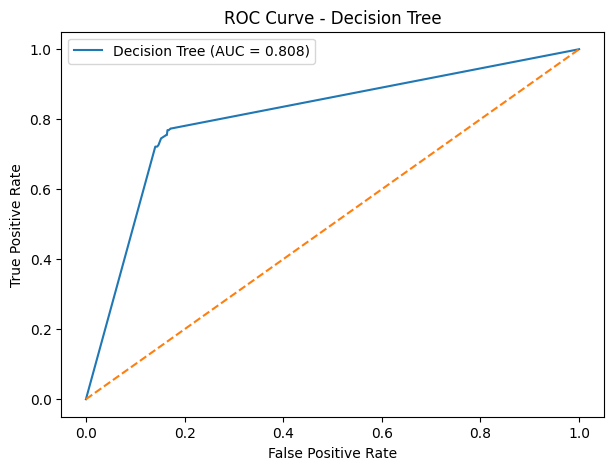

In [62]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive class (1)
y_proba = dt_model.predict_proba(X_test)[:, 1]

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# AUC
auc = roc_auc_score(y_test, y_proba)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

## Custom Threshold Calculation


In [64]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

thresholds = np.arange(0.10, 0.91, 0.01)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

threshold_scores = []

for threshold in thresholds:
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # Fit model
        dt_model.fit(X_tr, y_tr)

        # Probability of class 1
        y_proba = dt_model.predict_proba(X_val)[:, 1]

        # Apply threshold
        y_pred = (y_proba >= threshold).astype(int)

        # F1 for class 1
        scores.append(
            f1_score(y_val, y_pred, pos_label=1)
        )

    threshold_scores.append(np.mean(scores))


# Best threshold
best_idx = np.argmax(threshold_scores)

best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best CV Class 1 F1:", threshold_scores[best_idx])

Best Threshold: 0.5099999999999998
Best CV Class 1 F1: 0.6115015073119198


## SVM Pipeline

In [76]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

pipeline2 = Pipeline([
    ("scalers", StandardScaler()),
        ("oversamplers", SMOTE
         (random_state=42)),
    ("svc", SVC(probability=True, random_state=42))
])


param = {
    "svc__C": [0.01, 0.1, 1, 10, 100,200,300,400,500],
    "svc__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "svc__kernel": ["rbf"],
    "svc__class_weight": [None]
}

svc_cv = GridSearchCV(
    pipeline2,
    param_grid=param,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=2
)

svc_cv.fit(X_train, y_train)
y_pred_svm = svc_cv.predict(X_test)
print("Best CV weighted-F1:", svc_cv.best_score_)

svc_model = svc_cv.best_estimator_
print("Best Parameters:", svc_cv.best_params_)

print(classification_report(y_test, y_pred_svm))

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best CV weighted-F1: 0.8246549502894645
Best Parameters: {'svc__C': 500, 'svc__class_weight': None, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       768
           1       0.63      0.70      0.66       212

    accuracy                           0.84       980
   macro avg       0.77      0.79      0.78       980
weighted avg       0.85      0.84      0.85       980



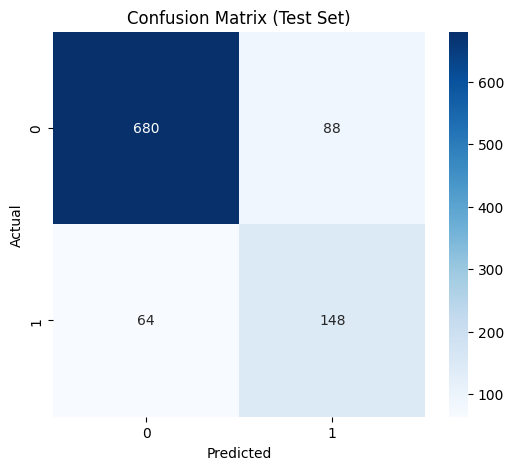

In [77]:
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set)")
plt.show()